# ============================================================
# TASK 2: Customer Segmentation Using Unsupervised Learning
# DevelopersHub Corporation – Data Science Internship
# ============================================================

In [1]:
!pip install scikit-learn matplotlib seaborn pandas numpy --quiet

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [11]:

import io

# Working direct download link
url = "https://raw.githubusercontent.com/SteffiPeTaffy/machineLearningAZ/master/Machine%20Learning%20A-Z%20Template%20Folder/Part%204%20-%20Clustering/Section%2025%20-%20Hierarchical%20Clustering/Mall_Customers.csv"

df = pd.read_csv(url)

# Rename columns for easier use
df.columns = ['CustomerID', 'Gender', 'Age', 'Annual_Income', 'Spending_Score']

print("Dataset loaded!")
print(f"Shape: {df.shape}")
print(df.head(10))

Dataset loaded!
Shape: (200, 5)
   CustomerID  Gender  Age  Annual_Income  Spending_Score
0           1    Male   19             15              39
1           2    Male   21             15              81
2           3  Female   20             16               6
3           4  Female   23             16              77
4           5  Female   31             17              40
5           6  Female   22             17              76
6           7  Female   35             18               6
7           8  Female   23             18              94
8           9    Male   64             19               3
9          10  Female   30             19              72


In [12]:
print("=== Dataset Info ===")
print(df.info())
print("\n=== Statistical Summary ===")
print(df.describe())
print("\n=== Missing Values ===")
print(df.isnull().sum())
print("\n=== Gender Distribution ===")
print(df['Gender'].value_counts())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   CustomerID      200 non-null    int64 
 1   Gender          200 non-null    object
 2   Age             200 non-null    int64 
 3   Annual_Income   200 non-null    int64 
 4   Spending_Score  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

=== Statistical Summary ===
       CustomerID         Age  Annual_Income  Spending_Score
count  200.000000  200.000000     200.000000      200.000000
mean   100.500000   38.850000      60.560000       50.200000
std     57.879185   13.969007      26.264721       25.823522
min      1.000000   18.000000      15.000000        1.000000
25%     50.750000   28.750000      41.500000       34.750000
50%    100.500000   36.000000      61.500000       50.000000
75%    150.250000   49.000000      78.000000       73.00

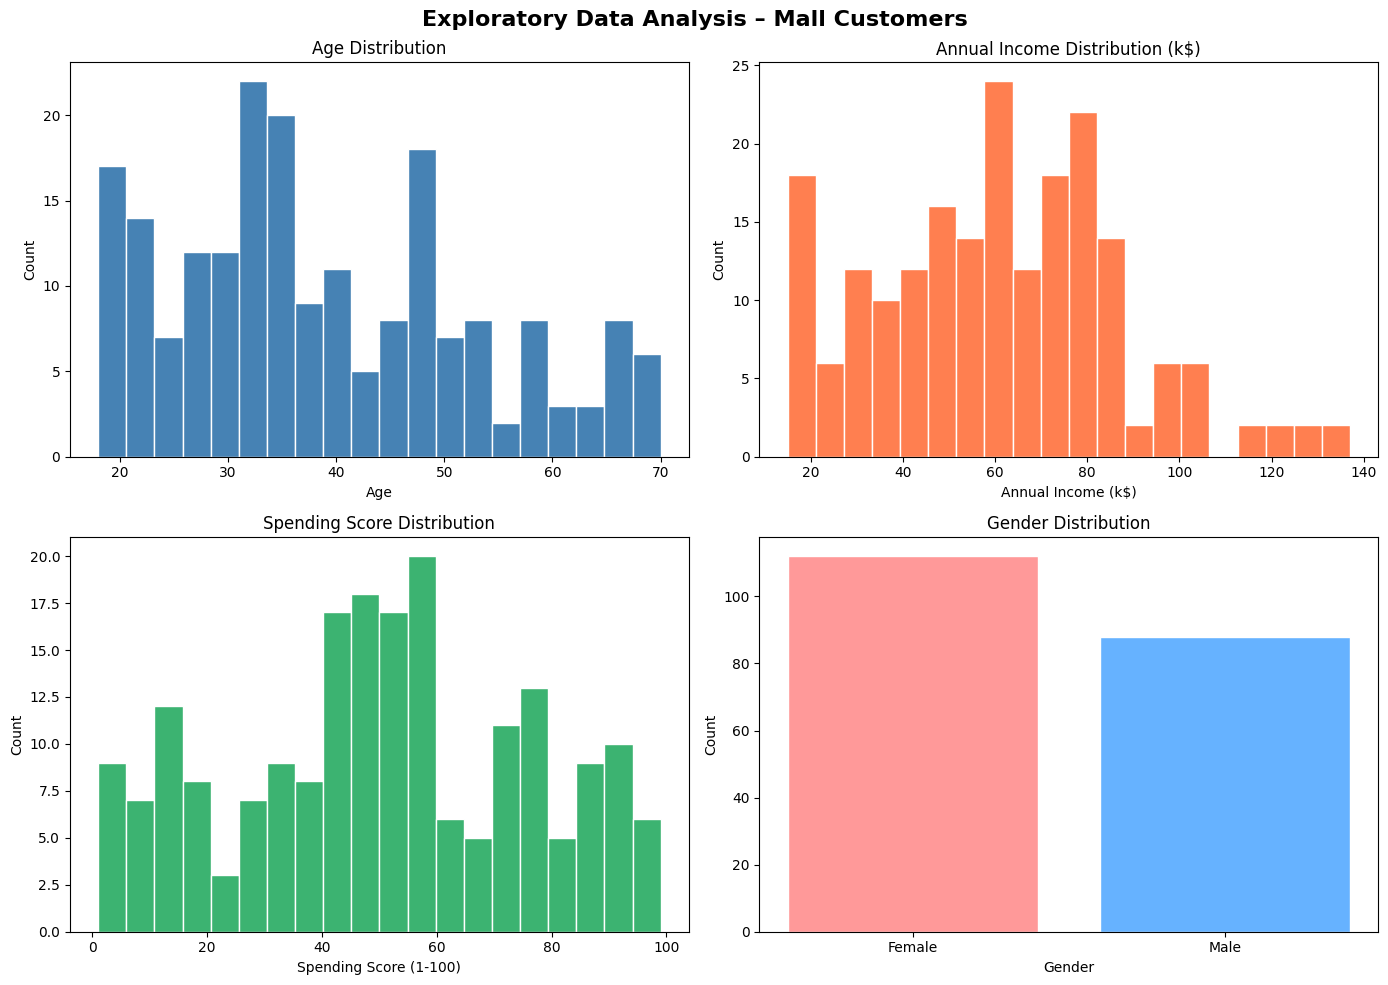

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Exploratory Data Analysis – Mall Customers', fontsize=16, fontweight='bold')

# Age distribution
axes[0, 0].hist(df['Age'], bins=20, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Age Distribution')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Count')

# Annual Income distribution
axes[0, 1].hist(df['Annual_Income'], bins=20, color='coral', edgecolor='white')
axes[0, 1].set_title('Annual Income Distribution (k$)')
axes[0, 1].set_xlabel('Annual Income (k$)')
axes[0, 1].set_ylabel('Count')

# Spending Score distribution
axes[1, 0].hist(df['Spending_Score'], bins=20, color='mediumseagreen', edgecolor='white')
axes[1, 0].set_title('Spending Score Distribution')
axes[1, 0].set_xlabel('Spending Score (1-100)')
axes[1, 0].set_ylabel('Count')

# Gender count
gender_counts = df['Gender'].value_counts()
axes[1, 1].bar(gender_counts.index, gender_counts.values,
               color=['#FF9999', '#66B2FF'], edgecolor='white')
axes[1, 1].set_title('Gender Distribution')
axes[1, 1].set_xlabel('Gender')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()

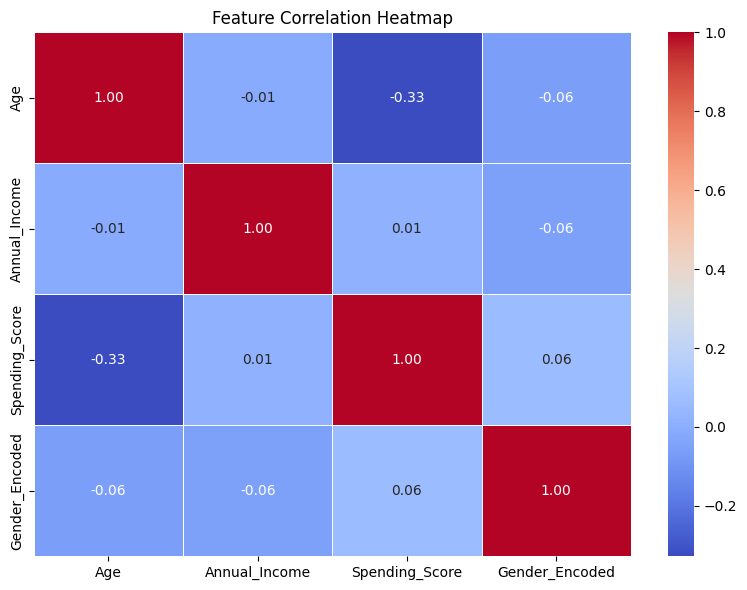

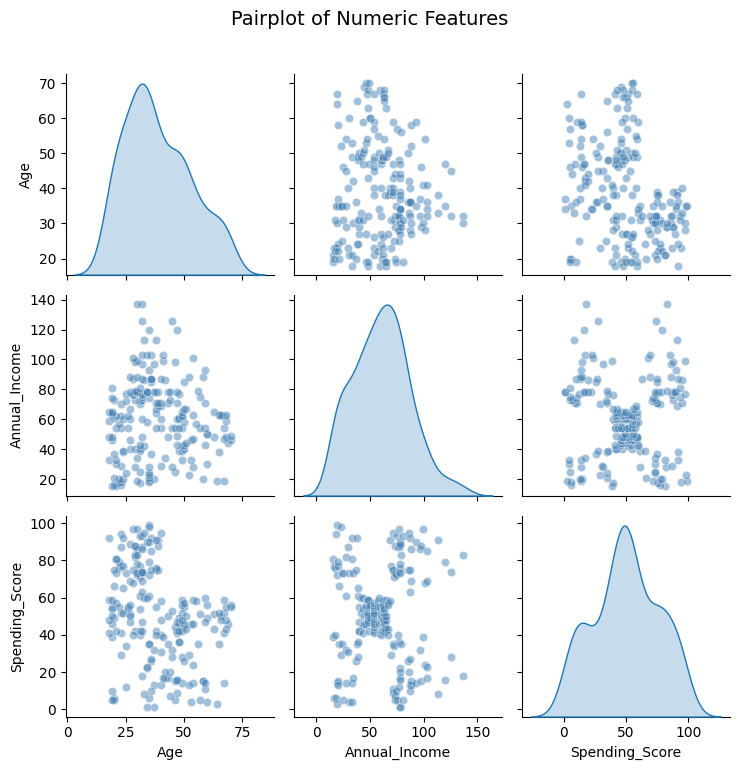

In [14]:
df['Gender_Encoded'] = df['Gender'].map({'Male': 0, 'Female': 1})

plt.figure(figsize=(8, 6))
sns.heatmap(df[['Age', 'Annual_Income', 'Spending_Score', 'Gender_Encoded']].corr(),
            annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# Pairplot
sns.pairplot(df[['Age', 'Annual_Income', 'Spending_Score']],
             diag_kind='kde', plot_kws={'alpha': 0.5, 'color': 'steelblue'})
plt.suptitle('Pairplot of Numeric Features', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


In [15]:
X = df[['Annual_Income', 'Spending_Score']].values

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Features selected: Annual_Income, Spending_Score")
print(f"Scaled data shape: {X_scaled.shape}")

Features selected: Annual_Income, Spending_Score
Scaled data shape: (200, 2)


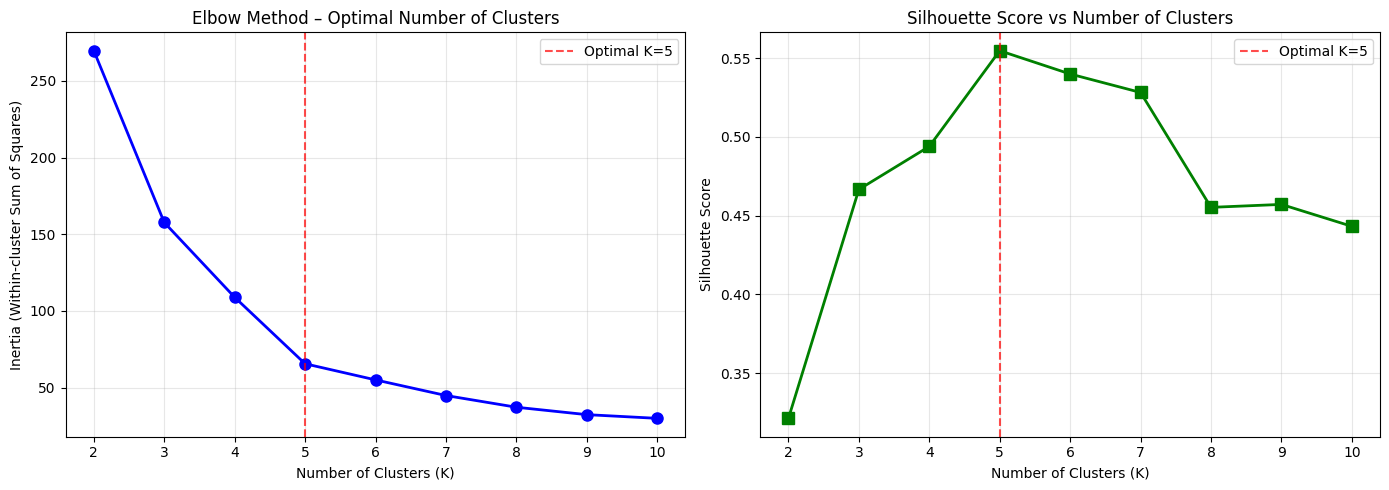


Best Silhouette Score: 0.5547 at K=5


In [16]:
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Curve
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(x=5, color='red', linestyle='--', alpha=0.7, label='Optimal K=5')
axes[0].set_title('Elbow Method – Optimal Number of Clusters')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (Within-cluster Sum of Squares)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Silhouette Score
axes[1].plot(K_range, silhouette_scores, 'gs-', linewidth=2, markersize=8)
axes[1].axvline(x=5, color='red', linestyle='--', alpha=0.7, label='Optimal K=5')
axes[1].set_title('Silhouette Score vs Number of Clusters')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nBest Silhouette Score: {max(silhouette_scores):.4f} at K={list(K_range)[silhouette_scores.index(max(silhouette_scores))]}")


In [17]:
OPTIMAL_K = 5

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print(f"K-Means clustering done with K={OPTIMAL_K}")
print(f"\nCluster distribution:")
print(df['Cluster'].value_counts().sort_index())
print(f"\nFinal Silhouette Score: {silhouette_score(X_scaled, df['Cluster']):.4f}")


K-Means clustering done with K=5

Cluster distribution:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

Final Silhouette Score: 0.5547


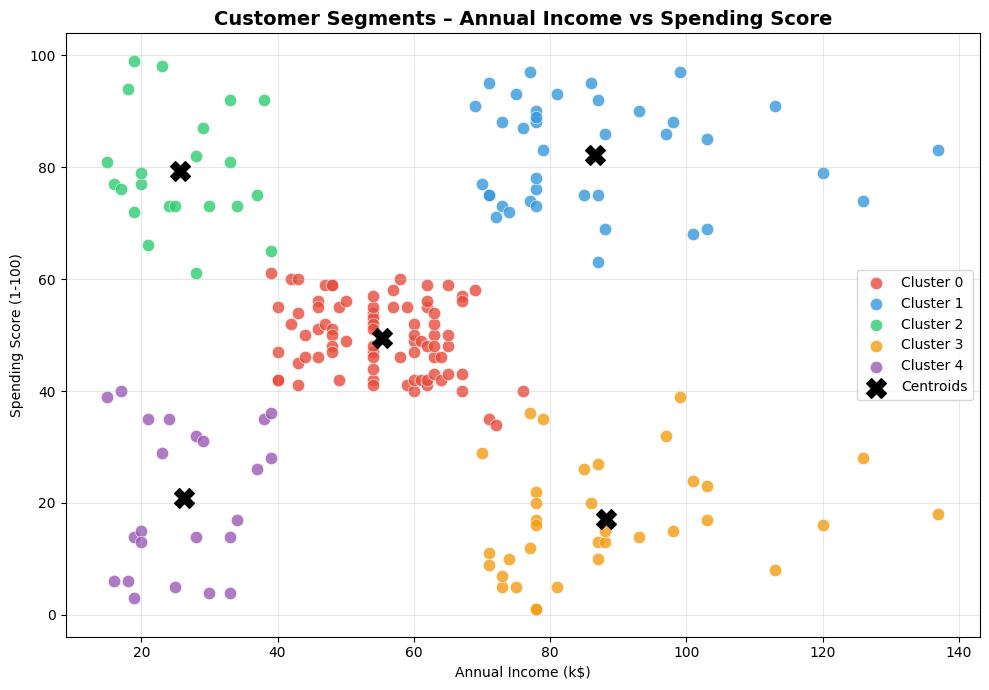

In [18]:
colors = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6']
cluster_names = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4']

plt.figure(figsize=(10, 7))
for i in range(OPTIMAL_K):
    mask = df['Cluster'] == i
    plt.scatter(df.loc[mask, 'Annual_Income'],
                df.loc[mask, 'Spending_Score'],
                c=colors[i], label=f'Cluster {i}',
                s=80, alpha=0.8, edgecolors='white', linewidth=0.5)

# Plot centroids (inverse transform to original scale)
centroids_original = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids_original[:, 0], centroids_original[:, 1],
            c='black', s=200, marker='X', label='Centroids', zorder=5)

plt.title('Customer Segments – Annual Income vs Spending Score', fontsize=14, fontweight='bold')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

PCA Explained Variance: PC1=44.27%, PC2=33.31%, Total=77.57%


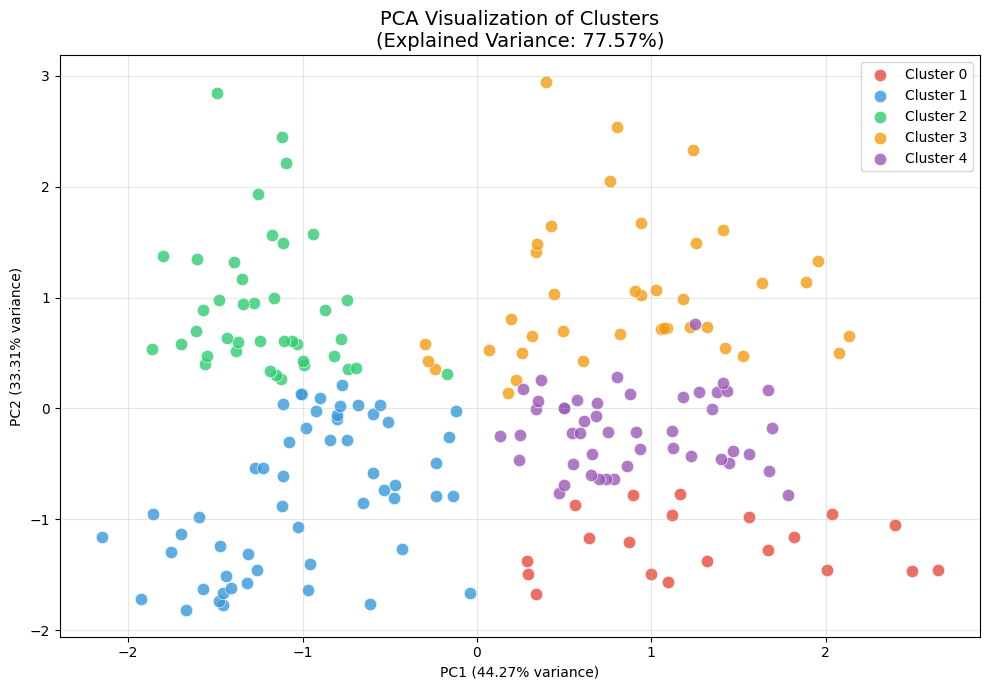

In [19]:
X_full = df[['Age', 'Annual_Income', 'Spending_Score']].values
X_full_scaled = StandardScaler().fit_transform(X_full)

# Re-cluster on full features for PCA view
kmeans_pca = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
labels_pca = kmeans_pca.fit_predict(X_full_scaled)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_full_scaled)

explained_var = pca.explained_variance_ratio_
print(f"PCA Explained Variance: PC1={explained_var[0]:.2%}, PC2={explained_var[1]:.2%}, Total={sum(explained_var):.2%}")

plt.figure(figsize=(10, 7))
for i in range(OPTIMAL_K):
    mask = labels_pca == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors[i], label=f'Cluster {i}',
                s=80, alpha=0.8, edgecolors='white', linewidth=0.5)

plt.title(f'PCA Visualization of Clusters\n(Explained Variance: {sum(explained_var):.2%})', fontsize=14)
plt.xlabel(f'PC1 ({explained_var[0]:.2%} variance)')
plt.ylabel(f'PC2 ({explained_var[1]:.2%} variance)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Running t-SNE (may take ~30 seconds)...


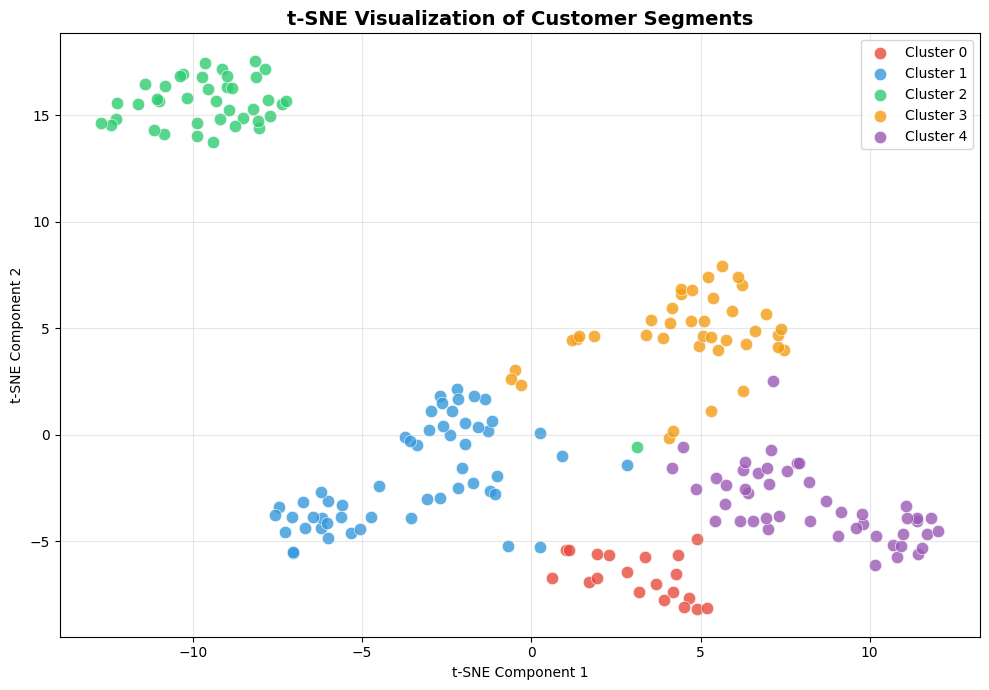

In [20]:
print("Running t-SNE (may take ~30 seconds)...")

tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_full_scaled)

plt.figure(figsize=(10, 7))
for i in range(OPTIMAL_K):
    mask = labels_pca == i
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                c=colors[i], label=f'Cluster {i}',
                s=80, alpha=0.8, edgecolors='white', linewidth=0.5)

plt.title('t-SNE Visualization of Customer Segments', fontsize=14, fontweight='bold')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

=== Cluster Profiles ===
          Age  Annual_Income  Spending_Score  Count  Female_%
Cluster                                                      
0        42.7           55.3            49.5     81      59.3
1        32.7           86.5            82.1     39      53.8
2        25.3           25.7            79.4     22      59.1
3        41.1           88.2            17.1     35      45.7
4        45.2           26.3            20.9     23      60.9


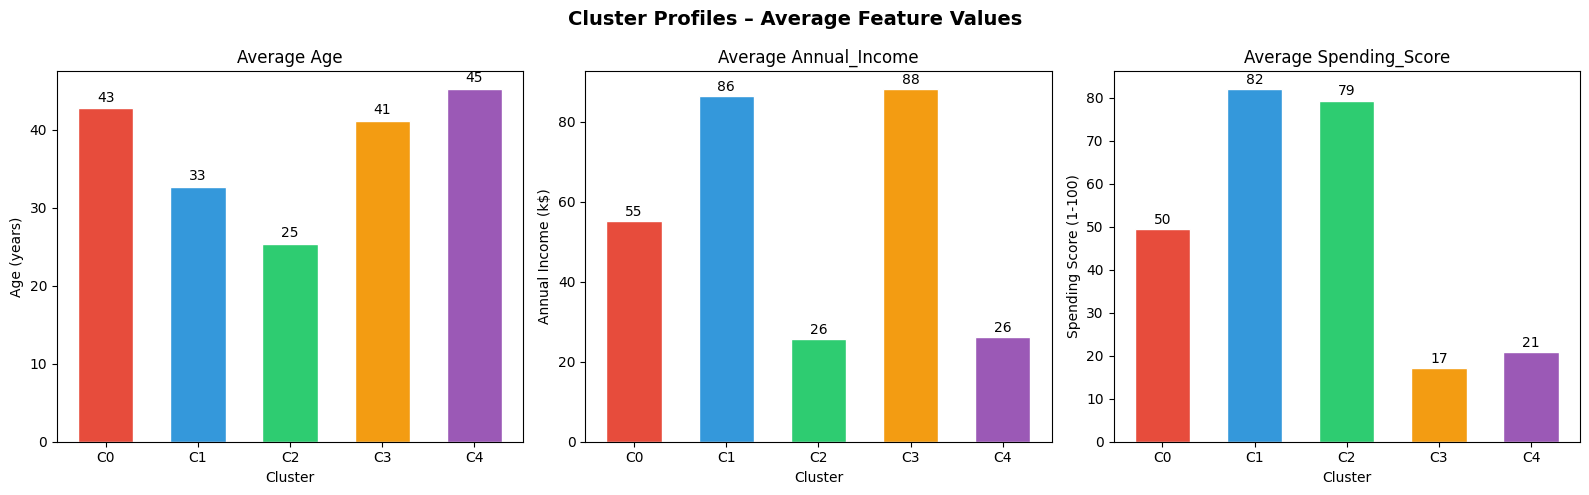

In [21]:
cluster_profile = df.groupby('Cluster')[['Age', 'Annual_Income', 'Spending_Score']].mean().round(1)
cluster_profile['Count'] = df.groupby('Cluster')['CustomerID'].count()
cluster_profile['Female_%'] = (df.groupby('Cluster')['Gender_Encoded'].mean() * 100).round(1)

print("=== Cluster Profiles ===")
print(cluster_profile)

# Visual profile chart
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Cluster Profiles – Average Feature Values', fontsize=14, fontweight='bold')

features = ['Age', 'Annual_Income', 'Spending_Score']
ylabels  = ['Age (years)', 'Annual Income (k$)', 'Spending Score (1-100)']

for idx, (feat, ylabel) in enumerate(zip(features, ylabels)):
    vals = [cluster_profile.loc[i, feat] for i in range(OPTIMAL_K)]
    bars = axes[idx].bar(range(OPTIMAL_K), vals, color=colors, edgecolor='white', width=0.6)
    axes[idx].set_title(f'Average {feat}')
    axes[idx].set_xlabel('Cluster')
    axes[idx].set_ylabel(ylabel)
    axes[idx].set_xticks(range(OPTIMAL_K))
    axes[idx].set_xticklabels([f'C{i}' for i in range(OPTIMAL_K)])
    for bar, val in zip(bars, vals):
        axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                       f'{val:.0f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


In [23]:
segment_labels = {
    0: 'Low Income, Low Spenders',
    1: 'High Income, Low Spenders',
    2: 'Average Income, Average Spenders',
    3: 'Low Income, High Spenders',
    4: 'High Income, High Spenders'
}

strategies = {
    0: 'Budget offers, discount coupons, loyalty rewards programs',
    1: 'Premium product awareness campaigns, personalized offers to unlock spending',
    2: 'Upselling mid-range products, membership programs, referral incentives',
    3: 'Credit/EMI options, budget-friendly premium alternatives, retention focus',
    4: 'VIP membership, exclusive deals, luxury products, early access to new items'
}

print("\n" + "="*65)
print("       CUSTOMER SEGMENT MARKETING STRATEGIES")
print("="*65)

for cluster_id in range(OPTIMAL_K):
    profile = cluster_profile.loc[cluster_id]
    print(f"\n📌 Cluster {cluster_id} — {segment_labels.get(cluster_id, '')}")
    print(f"   Customers : {int(profile['Count'])}")
    print(f"   Avg Age   : {profile['Age']:.0f} yrs")
    print(f"   Avg Income: ${profile['Annual_Income']:.0f}k")
    print(f"   Avg Score : {profile['Spending_Score']:.0f}/100")
    print(f"   Strategy  : {strategies.get(cluster_id, '')}")

print("\n" + "="*65)


       CUSTOMER SEGMENT MARKETING STRATEGIES

📌 Cluster 0 — Low Income, Low Spenders
   Customers : 81
   Avg Age   : 43 yrs
   Avg Income: $55k
   Avg Score : 50/100
   Strategy  : Budget offers, discount coupons, loyalty rewards programs

📌 Cluster 1 — High Income, Low Spenders
   Customers : 39
   Avg Age   : 33 yrs
   Avg Income: $86k
   Avg Score : 82/100
   Strategy  : Premium product awareness campaigns, personalized offers to unlock spending

📌 Cluster 2 — Average Income, Average Spenders
   Customers : 22
   Avg Age   : 25 yrs
   Avg Income: $26k
   Avg Score : 79/100
   Strategy  : Upselling mid-range products, membership programs, referral incentives

📌 Cluster 3 — Low Income, High Spenders
   Customers : 35
   Avg Age   : 41 yrs
   Avg Income: $88k
   Avg Score : 17/100
   Strategy  : Credit/EMI options, budget-friendly premium alternatives, retention focus

📌 Cluster 4 — High Income, High Spenders
   Customers : 23
   Avg Age   : 45 yrs
   Avg Income: $26k
   Avg Score : 

In [24]:
print("\n" + "="*55)
print("         TASK 2 – FINAL SUMMARY")
print("="*55)
print(f"  Dataset          : Mall Customers")
print(f"  Total Customers  : {len(df)}")
print(f"  Features Used    : Age, Annual Income, Spending Score")
print(f"  Optimal Clusters : {OPTIMAL_K} (Elbow + Silhouette)")
print(f"  Silhouette Score : {silhouette_score(X_scaled, df['Cluster']):.4f}")
print(f"  PCA Variance     : {sum(explained_var):.2%}")
print()
print("K-Means clustering complete")
print("PCA & t-SNE visualizations generated")
print("Marketing strategies defined per segment")
print("="*55)


         TASK 2 – FINAL SUMMARY
  Dataset          : Mall Customers
  Total Customers  : 200
  Features Used    : Age, Annual Income, Spending Score
  Optimal Clusters : 5 (Elbow + Silhouette)
  Silhouette Score : 0.5547
  PCA Variance     : 77.57%

K-Means clustering complete
PCA & t-SNE visualizations generated
Marketing strategies defined per segment
